# Quickstart: NASA IMERG analysis, late - dynamical.org Icechunk Zarr

NASA's IMERG (Integrated Multi-satellitE Retrievals for GPM) merges precipitation estimates from a constellation of microwave and infrared satellites, gauge-adjusted, into a seamless global record of rain and snow.

This product provides global, half-hourly precipitation at 0.1 degree (~10km) resolution from 1998 to present, from the IMERG Late Run, transformed into an analysis-ready Zarr store by [dynamical.org](https://dynamical.org). A lower-latency sibling, `nasa-imerg-analysis-early`, trades some quality for a ~4 hour update lag instead of ~12-18 hours.

Dataset documentation: https://dynamical.org/catalog/nasa-imerg-analysis-late/

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog

In [2]:
import dynamical_catalog

ds = dynamical_catalog.open("nasa-imerg-analysis-late", chunks=None)
ds

<xarray.Dataset> Size: 26TB
Dimensions:                              (time: 500710, latitude: 1800,
                                          longitude: 3600)
Coordinates:
  * time                                 (time) datetime64[ns] 4MB 1998-01-01...
  * latitude                             (latitude) float64 14kB 89.95 ... -8...
  * longitude                            (longitude) float64 29kB -179.9 ... ...
    spatial_ref                          int64 8B ...
Data variables:
    precipitation_quality_index_surface  (time, latitude, longitude) float32 13TB ...
    precipitation_surface                (time, latitude, longitude) float32 13TB ...
Attributes:
    dataset_id:          nasa-imerg-analysis-late
    dataset_version:     0.1.0
    name:                NASA IMERG analysis, late
    description:         Global half-hourly precipitation from NASA GPM IMERG...
    attribution:         NASA GPM IMERG data processed by dynamical.org from ...
    license:             CC-BY-4.0
    spatial_domain:      Global
    spatial_resolution:  0.1 degrees (~10km)
    time_domain:         1998-01-01 00:00:00 UTC to Present
    time_resolution:     30 minutes

This is a single Zarr store that opens directly with xarray. It has two variables: `precipitation_surface`, the precipitation rate (`kg m-2 s-1`, equivalent to mm/s), and `precipitation_quality_index_surface`, a dimensionless 0-1 confidence score for each estimate.

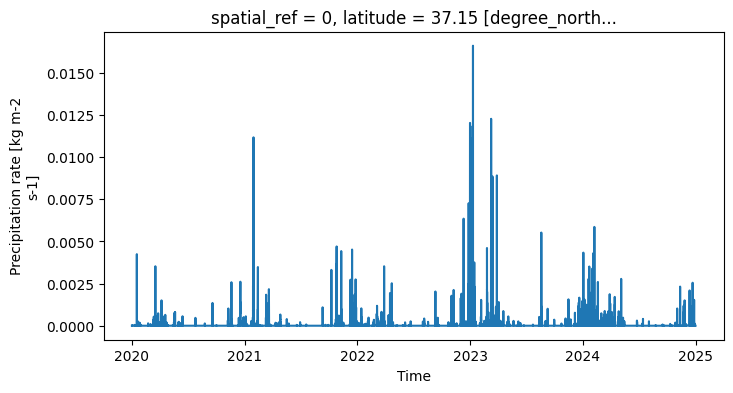

In [3]:
# Sierra Nevada Mountains, California, US
# The 2022-2023 winter brought significant atmospheric river precipitation events
(
    ds["precipitation_surface"]
    .sel(time=slice("2020", "2024"))
    .sel(latitude=37.15, longitude=-119.5, method="nearest")
    .plot(size=4, aspect=2)
)

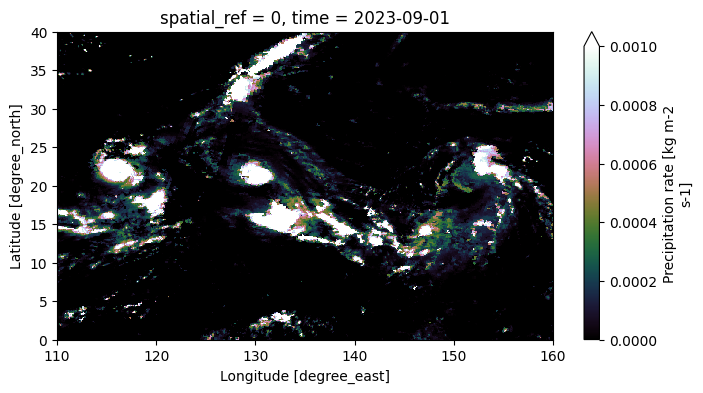

In [4]:
# Precipitation over east Asia and the western Pacific Ocean
(
    ds["precipitation_surface"]
    .sel(time="2023-09-01T00:00")
    .sel(latitude=slice(40, 0), longitude=slice(110, 160))
    .plot(cmap="cubehelix", vmax=0.001, size=4, aspect=2)
)

### When do the monsoons arrive?

Pull several years for two cities and watch the wet seasons swap between hemispheres. Each city's rate is aggregated to a monthly mean.

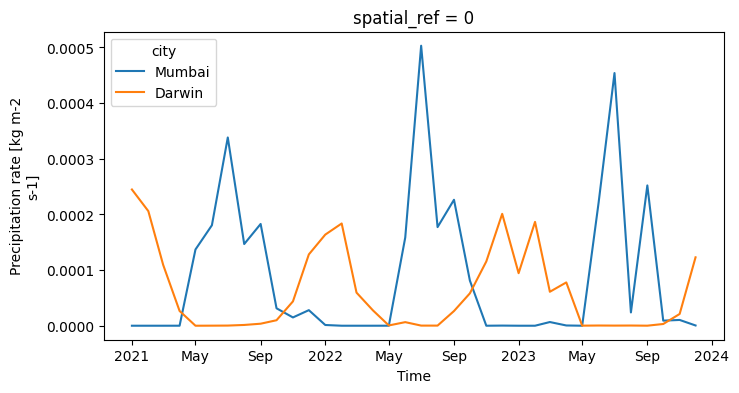

In [5]:
import pandas as pd

cities = pd.DataFrame([
    {"city": "Mumbai", "latitude": 19.07, "longitude": 72.87},
    {"city": "Darwin", "latitude": -12.46, "longitude": 130.84},
]).set_index("city").to_xarray()

(
    ds["precipitation_surface"]
    .sel(time=slice("2021", "2023"))
    .sel(latitude=cities.latitude, longitude=cities.longitude, method="nearest")
    .load()
    .resample(time="1MS").mean()
    .plot(hue="city", size=4, aspect=2)
)

### Where are the highest-quality retrievals?

Every estimate carries a companion quality index. Plotting it highlights how satellite observations, visible as north-south swaths, improve data quality. This quality map is continuously changing based on the latest observations; here we show a snapshot at a single moment in time.

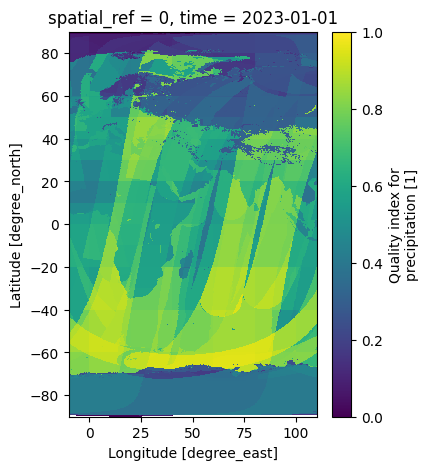

In [6]:
(
    ds["precipitation_quality_index_surface"]
    .sel(time="2023-01-01T00:00")
    .sel(longitude=slice(-10, 110))
    .plot(cmap="viridis", vmin=0, vmax=1, size=5, aspect=0.8)
)

### Animated map: an atmospheric river filling up California

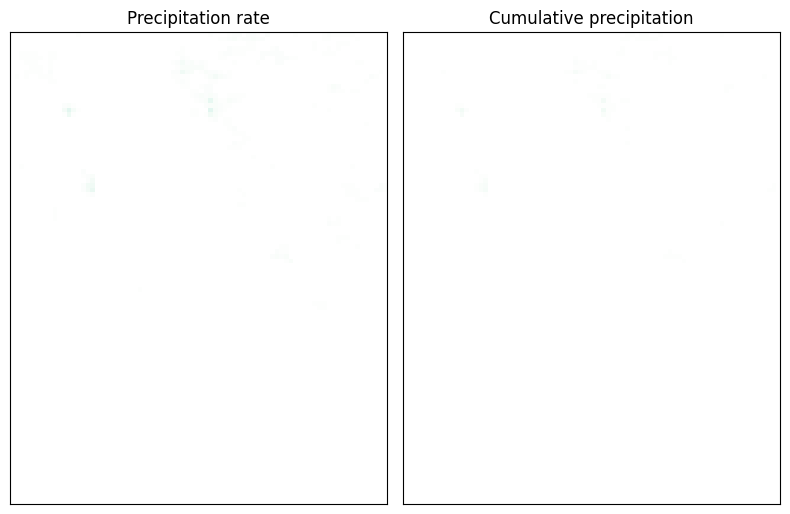

In [7]:
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

data = (
    ds["precipitation_surface"]
    .sel(
        time=slice("2022-12-26", "2023-01-05"),
        latitude=slice(42, 32),
        longitude=slice(-125, -117),
    )
    .load()
    .resample(time="6h").mean()
)
cumulative = data.cumsum("time")

fig, (ax_now, ax_sum) = plt.subplots(1, 2, figsize=(8, 5.5))
for ax in (ax_now, ax_sum):
    ax.set(xticks=[], yticks=[])
ax_now.set_title("Precipitation rate")
ax_sum.set_title("Cumulative precipitation")
fig.tight_layout()

img_now = ax_now.imshow(data.isel(time=0), cmap="cubehelix_r", vmin=0, vmax=data.max())
img_sum = ax_sum.imshow(cumulative.isel(time=0), cmap="cubehelix_r", vmin=0, vmax=cumulative.max())

def update(i):
    img_now.set_data(data.isel(time=i))
    img_sum.set_data(cumulative.isel(time=i))
    return img_now, img_sum

anim = FuncAnimation(fig=fig, frames=data.time.size, func=update, interval=150)
HTML(anim.to_jshtml())

### Community challenge

With 28 years of global, half-hourly precipitation, there is a lot to explore.

Here are a few for inspiration:
- Are short-duration rainfall extremes becoming more frequent? Count grid cells exceeding an intense threshold each year and look for trends by region.
- Combine IMERG with a storm-track dataset like IBTrACS to build composite rainfall swaths around tropical cyclones.
- Compare `nasa-imerg-analysis-early` against this Late Run for the same events to see how much the extra latency improves the estimate.